# Настройка статических ключевых слов: task (English)

Ноутбук демонстрирует полный цикл настройки словаря для аспекта **task** на SciREx и сравнивает извлечение до настройки (`baseline`, без ключевых слов) и после настройки (`static-keywords`) на отложенной test-части.

Подробное описание алгоритма: `docs/keyword-tuning-algorithm.md`.

> Настройка использует эталоны только при построении train-evidence и выборе на dev. Test не участвует в выборе слов или стратегии.

## Режим запуска

- `sample`: быстрый воспроизводимый прогон на подвыборке. Подходит для проверки окружения и структуры эксперимента.
- `full`: весь датасет и activation-aware параметры (компактный словарь, 2–3 keywords).
- `full_large`: тот же датасет, но профиль для **большего словаря** (4–8 keywords): `union`, `min-keywords=4`, ослабленный activation gate.
- `TUNING_STRATEGIES`: список конкретных троек `(score, cluster, answer)`; `None` запускает полный перебор 27 комбинаций.

Evidence, метрики и checkpoints кэшируются. Повторный запуск с теми же параметрами продолжает поиск и не повторяет QA.

In [1]:
from __future__ import annotations

import importlib.util
import json
import logging
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "untie").is_dir():
            return candidate
    raise RuntimeError("Не найден корень UnTIE_project")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Импорт CLI-скрипта по пути: имя файла начинается с цифр и не является обычным Python-модулем.
spec = importlib.util.spec_from_file_location(
    "untie_tuning_cli", PROJECT_ROOT / "scripts" / "05_Tune_model_keywords.py"
)
if spec is None or spec.loader is None:
    raise RuntimeError("Не удалось загрузить scripts/05_Tune_model_keywords.py")
tuning_cli = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tuning_cli)

from untie.cli import load_static_keywords
from untie.extraction_metrics import METRIC_COLUMNS, compute_metrics_rowwise
from untie.keyword_evidence import CachedDocumentEvidence, rerank_cached_document
from untie.keyword_training import candidate_evidence_from_documents
from untie.keyword_tuning import aggregate_candidate_pool, deterministic_document_split

logging.basicConfig(level=logging.WARNING)
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Python = {sys.version.split()[0]}")

/home/aiserver/POLINA/UnTIE_project/untie_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT = /home/aiserver/POLINA/UnTIE_project
Python = 3.12.3


In [2]:
# Главный переключатель: "sample", "full" или "full_large".
RUN_MODE = "full_large"
assert RUN_MODE in {"sample", "full", "full_large"}

LANGUAGE = "en"
SEED = 42
SAMPLE_SIZE = 20
DEVICE = "auto"

EVAL_BERTSCORE = True
TUNING_BERTSCORE = RUN_MODE in {"full", "full_large"}

# None означает полный перебор 27 комбинаций. Чтобы проверить только выбранные
# стратегии, перечислите одну или несколько троек (score, cluster, answer).
TUNING_STRATEGIES = (
    [
        ("equal_weight_score_diff", "weighted_score", "combined_score"),
        # ("only_score_diff", "highest_avg_score", "highest_similarity"),
    ]
    if RUN_MODE == "sample"
    else None
)

VALID_SCORE_STRATEGIES = {"only_score_diff", "only_weight", "equal_weight_score_diff"}
VALID_CLUSTER_STRATEGIES = {"highest_avg_score", "weighted_score", "highest_cohesion"}
VALID_ANSWER_STRATEGIES = {"highest_chunk_score", "highest_similarity", "combined_score"}
for score_name, cluster_name, answer_name in TUNING_STRATEGIES or []:
    if score_name not in VALID_SCORE_STRATEGIES:
        raise ValueError(f"Неизвестная score strategy: {score_name}")
    if cluster_name not in VALID_CLUSTER_STRATEGIES:
        raise ValueError(f"Неизвестная cluster strategy: {cluster_name}")
    if answer_name not in VALID_ANSWER_STRATEGIES:
        raise ValueError(f"Неизвестная answer strategy: {answer_name}")

required_metric_modules = ["evaluate", "rouge_score"]
if EVAL_BERTSCORE or TUNING_BERTSCORE:
    required_metric_modules.append("bert_score")
missing_metric_modules = [
    name for name in required_metric_modules if importlib.util.find_spec(name) is None
]
if missing_metric_modules:
    raise RuntimeError(
        "Не установлены зависимости метрик: "
        f"{missing_metric_modules}. Установите проект с extras: pip install -e '.[evaluation]'"
    )

DATASET_PATH = PROJECT_ROOT / "datasets" / "scirex_structured.json"
INIT_MODEL_PATH = PROJECT_ROOT / "model_params" / "scart_init_model.json"
OUTPUT_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "analysis_results"
    / "keyword_tuning_task"
    / LANGUAGE
    / RUN_MODE
)
CACHE_DIR = PROJECT_ROOT / "artifacts" / "keyword_tuning_notebooks"
TUNED_MODEL_PATH = OUTPUT_DIR / "scart_tuned_model.json"
TRACE_PATH = OUTPUT_DIR / "scart_tuned_model.tuning.json"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

profile_summary = {
    "mode": RUN_MODE,
    "dataset": str(DATASET_PATH),
    "sample_size": SAMPLE_SIZE if RUN_MODE == "sample" else "all",
    "strategies": TUNING_STRATEGIES or "all 27 combinations",
    "tuning_bertscore": TUNING_BERTSCORE,
    "evaluation_bertscore": EVAL_BERTSCORE,
    "output": str(OUTPUT_DIR),
}
display(pd.Series(profile_summary, name="value").to_frame())

,value
mode,full
dataset,/home/aiserver/POLINA/UnTIE_project/datasets/s...
sample_size,all
strategies,all 27 combinations
tuning_bertscore,True
evaluation_bertscore,True
output,/home/aiserver/POLINA/UnTIE_project/experiment...


In [3]:
dataset = tuning_cli.load_training_dataset(DATASET_PATH, LANGUAGE)
if RUN_MODE == "sample":
    dataset = dataset.iloc[:SAMPLE_SIZE].copy()
if len(dataset) < 5:
    raise ValueError("Для непустых train/dev/test требуется как минимум 5 документов")

split = deterministic_document_split(dataset["doc_id"], seed=SEED)
split_rows = []
for split_name, doc_ids in split.items():
    split_rows.append({"split": split_name, "documents": len(doc_ids), "example_ids": ", ".join(doc_ids[:3])})

display(pd.DataFrame(split_rows))
display(dataset[["doc_id", "tasks_cleaned"]].head())
print(f"Документов после нормализации: {len(dataset)}")
print("Пересечения split:", set(split["train"]) & set(split["dev"]), set(split["train"]) & set(split["test"]))

,split,documents,example_ids
0,train,183,"27e4b65121d3c88643d86dc91a9bdafdf223b988, 0cfd..."
1,dev,61,"40b4596a0ae4f4ff065f3f13f36db39543e50068, 1db9..."
2,test,62,"45b559e6271570598602fcf9777ed6f2f2d133e6, 0012..."


,doc_id,tasks_cleaned
0,000f90380d768a85e2316225854fc377c079b5c4,"[Semantic Segmentation, Real-Time Semantic Seg..."
1,0012de6bec1f25599e4f02517637e531a71909b9,[Volumetric Medical Image Segmentation]
2,007ab5528b3bd310a80d553cccad4b78dc496b02,"[Question Answering, Open-Domain Question Answ..."
3,0095c269e7d0c990249312687fc43521019809c4,[Natural Language Inference]
4,00b1cdc5bd77bf27f9b1ca630365eeeb456913b4,"[Game of Go, Game of Shogi]"


Документов после нормализации: 306
Пересечения split: set() set()


## Настройка

Следующая ячейка запускает официальный orchestration из `05_Tune_model_keywords.py`. Progress callback показывает отдельно сбор evidence, prescreening кандидатов, перебор стратегий и stability runs.

**Retune from cache:** если evidence уже собран (каталог `--cache-dir` заполнен), повторный запуск пропускает дорогой QA/attention и выполняет только tuning. Для `RUN_MODE = "full"` автоматически включаются улучшенные параметры: `relaxed` selection, prescreen top-40, exact-match objective.

In [4]:
class NotebookProgress:
    def __init__(self) -> None:
        self.events: list[dict] = []
        self.evidence_bar = None
        self.strategy_bar = None
        self.stability_bar = None

    @staticmethod
    def _advance(bar, current: int) -> None:
        bar.update(max(0, current - bar.n))

    def __call__(self, event: str, current: int, total: int, details) -> None:
        record = {"event": event, "current": current, "total": total, **dict(details)}
        self.events.append(record)
        if event == "evidence":
            if self.evidence_bar is None:
                self.evidence_bar = tqdm(total=total, desc="Evidence (QA + attention)", unit="doc")
            self._advance(self.evidence_bar, current)
            self.evidence_bar.set_postfix(
                source=details.get("source"), candidates=details.get("candidate_count")
            )
            if current == total:
                self.evidence_bar.close()
        elif event == "candidate_pool":
            print(f"Пул кандидатов после train-only фильтрации: {details['candidate_count']}")
        elif event == "strategy_start":
            if self.strategy_bar is None:
                self.strategy_bar = tqdm(total=total, desc="Стратегии", unit="strategy")
            if self.stability_bar is not None:
                self.stability_bar.close()
            self.stability_bar = tqdm(
                total=None,
                desc=f"Stability: {details['strategy']}",
                unit="run",
                leave=False,
            )
        elif event == "stability_run":
            if self.stability_bar is not None:
                self.stability_bar.total = total
                self._advance(self.stability_bar, current)
                self.stability_bar.set_postfix(
                    objective=f"{details['objective']:.4f}", stop=details["stop_reason"]
                )
        elif event == "strategy_complete":
            if self.stability_bar is not None:
                self.stability_bar.close()
                self.stability_bar = None
            self._advance(self.strategy_bar, current)
            self.strategy_bar.set_postfix(objective=f"{details['objective']:.4f}")
            if current == total:
                self.strategy_bar.close()
        elif event == "complete":
            print(
                f"Готово: strategy={details['strategy']}, "
                f"keywords={len(details['keywords'])}, objective={details['objective']:.4f}"
            )


cli_args = [
    "--language", LANGUAGE,
    "--dataset", str(DATASET_PATH),
    "--model-params", str(INIT_MODEL_PATH),
    "--output", str(TUNED_MODEL_PATH),
    "--trace", str(TRACE_PATH),
    "--cache-dir", str(CACHE_DIR),
    "--device", DEVICE,
    "--seed", str(SEED),
]
if RUN_MODE == "sample":
    cli_args += [
        "--limit", str(SAMPLE_SIZE),
        "--min-document-support", "1",
        "--max-candidates", "30",
        "--max-keywords", "5",
        "--evaluation-budget", "30",
        "--patience", "1",
        "--beam-width", "3",
        "--stability-runs", "2",
        "--stability-threshold", "0.5",
    ]
elif RUN_MODE == "full":
    cli_args += [
        "--selection-policy", "relaxed",
        "--stability-threshold", "0.4",
        "--require-non-empty",
        "--screen-top-k", "40",
        "--tuning-exact-match",
        "--no-enrich-train-references",
        "--min-activation-rate", "0.20",
        "--use-conditional-gain",
        "--inactive-fallback-penalty", "0.05",
        "--activation-weight", "0.15",
        "--win-rate-weight", "0.10",
        "--harm-cap", "0.12",
        "--min-enriched-support", "8",
    ]
elif RUN_MODE == "full_large":
    cli_args += [
        "--max-keywords", "8",
        "--min-keywords", "4",
        "--max-rescue-keywords", "8",
        "--selection-policy", "union",
        "--stability-threshold", "0.2",
        "--require-non-empty",
        "--screen-top-k", "60",
        "--tuning-exact-match",
        "--no-enrich-train-references",
        "--min-activation-rate", "0.15",
        "--use-conditional-gain",
        "--inactive-fallback-penalty", "0.04",
        "--activation-weight", "0.12",
        "--win-rate-weight", "0.08",
        "--harm-cap", "0.12",
        "--min-enriched-support", "6",
    ]
for strategy_values in TUNING_STRATEGIES or []:
    cli_args.extend(["--strategy", *strategy_values])
if TUNING_BERTSCORE:
    cli_args.append("--include-bertscore")

args = tuning_cli.build_parser().parse_args(cli_args)
progress = NotebookProgress()
outcome = tuning_cli.run(args, progress_callback=progress)
progress_df = pd.DataFrame(progress.events)
display(progress_df.tail(10))

Evidence (QA + attention): 100%|██████████| 306/306 [24:50<00:00,  4.87s/doc, candidates=0, source=computed]  


Пул кандидатов после train-only фильтрации: 150


Стратегии:   0%|          | 0/27 [00:00<?, ?strategy/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 6304.67it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

Loading weights: 100%|██████████| 389/389 [00:00<0

Готово: strategy=only_weight+weighted_score+highest_similarity, keywords=0, objective=-0.1000


,event,current,total,doc_id,candidate_count,source,collect_candidates,strategy,keywords,objective,stop_reason,evaluations_used,stability
487,stability_run,5,5,NaN,NaN,NaN,NaN,equal_weight_score_diff+highest_cohesion+highe...,"(strive,)",-0.097797,evaluation_budget,250.0,NaN
488,strategy_complete,26,27,NaN,NaN,NaN,NaN,equal_weight_score_diff+highest_cohesion+highe...,(),-0.100000,NaN,NaN,0.1
489,strategy_start,27,27,NaN,NaN,NaN,NaN,equal_weight_score_diff+highest_cohesion+combi...,NaN,NaN,NaN,NaN,NaN
490,stability_run,1,5,NaN,NaN,NaN,NaN,equal_weight_score_diff+highest_cohesion+combi...,"(formulate,)",-0.096281,evaluation_budget,250.0,NaN
491,stability_run,2,5,NaN,NaN,NaN,NaN,equal_weight_score_diff+highest_cohesion+combi...,"(strive,)",-0.097797,evaluation_budget,250.0,NaN
492,stability_run,3,5,NaN,NaN,NaN,NaN,equal_weight_score_diff+highest_cohesion+combi...,"(hypotheses,)",-0.095632,evaluation_budget,250.0,NaN
493,stability_run,4,5,NaN,NaN,NaN,NaN,equal_weight_score_diff+highest_cohesion+combi...,"(identify,)",-0.099157,evaluation_budget,250.0,NaN
494,stability_run,5,5,NaN,NaN,NaN,NaN,equal_weight_score_diff+highest_cohesion+combi...,"(strive,)",-0.097797,evaluation_budget,250.0,NaN
495,strategy_complete,27,27,NaN,NaN,NaN,NaN,equal_weight_score_diff+highest_cohesion+combi...,(),-0.100000,NaN,NaN,0.1
496,complete,1,1,NaN,NaN,NaN,NaN,only_weight+weighted_score+highest_similarity,(),-0.100000,NaN,NaN,NaN


,value
selected_strategy,only_weight+weighted_score+highest_similarity
keywords,[]
dev_objective,-0.1
dev_mean_gain,0.0
dev_harm_rate,0.0
dev_fallback_rate,1.0
stability,0.1
test_objective,-0.1
test_mean_gain,0.0
test_harm_rate,0.0


""


,term,doc_id,attention,score_diff,document_support,supporting_docs
0,training,,0.002040,0.051817,33,"(0116899fce00ffa4afee08b505300bb3968faf9f, 020..."
1,work,,0.001863,0.081352,30,"(01125e3c68edb420b8d884ff53fb38d9fbe4f2b8, 021..."
2,learning,,0.002047,0.092568,20,"(01125e3c68edb420b8d884ff53fb38d9fbe4f2b8, 021..."
3,study,,0.002279,0.108795,18,"(051b3763c2ad4e4271db712b0e9a4cfe298d05db, 061..."
4,learn,,0.002267,0.063788,18,"(01125e3c68edb420b8d884ff53fb38d9fbe4f2b8, 021..."
5,trained,,0.002168,0.083013,14,"(01125e3c68edb420b8d884ff53fb38d9fbe4f2b8, 020..."
6,task,,0.002966,0.107539,11,"(01125e3c68edb420b8d884ff53fb38d9fbe4f2b8, 020..."
7,propose,,0.002091,0.058543,11,"(01125e3c68edb420b8d884ff53fb38d9fbe4f2b8, 061..."
8,experiments,,0.002258,0.052062,10,"(01125e3c68edb420b8d884ff53fb38d9fbe4f2b8, 061..."
9,research,,0.002178,0.068693,9,"(03184ac97ebf0724c45a29ab49f2a8ce59ac2de3, 061..."


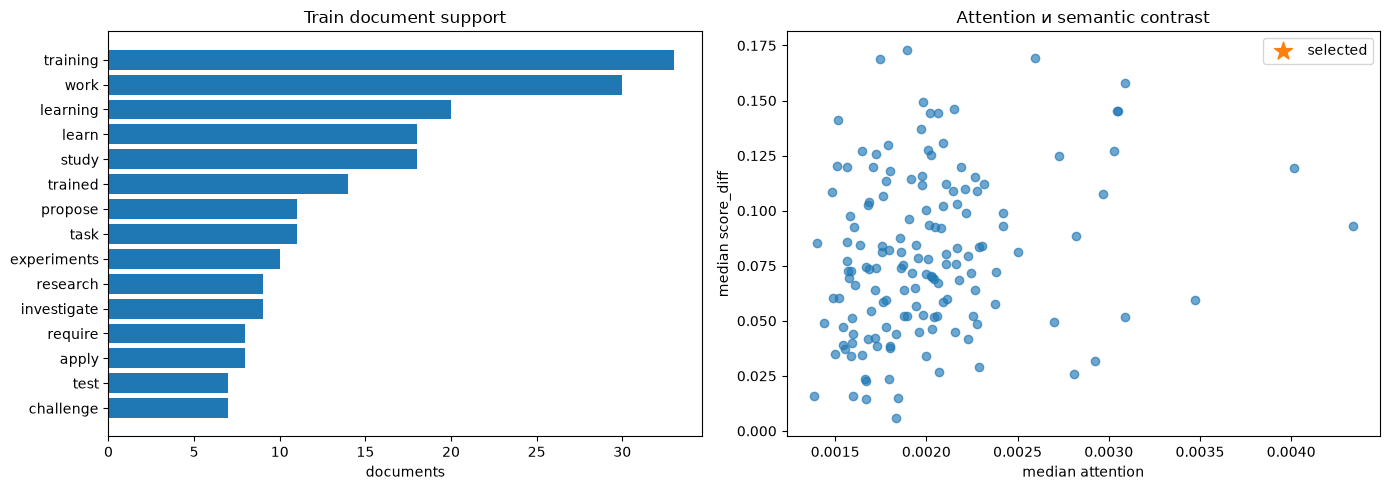

In [5]:
summary = {
    "selected_strategy": outcome.strategy.name,
    "keywords": list(outcome.keywords),
    "dev_objective": outcome.objective,
    "dev_mean_gain": outcome.mean_gain,
    "dev_mean_gain_active": outcome.mean_gain_active,
    "dev_activation_rate": outcome.activation_rate,
    "dev_win_rate": outcome.win_rate,
    "dev_loss_rate": outcome.loss_rate,
    "dev_harm_rate": outcome.harm_rate,
    "dev_fallback_rate": outcome.fallback_rate,
    "stability": outcome.stability,
    "test_objective": outcome.test_objective,
    "test_mean_gain": outcome.test_mean_gain,
    "test_mean_gain_active": outcome.test_mean_gain_active,
    "test_activation_rate": outcome.test_activation_rate,
    "test_win_rate": outcome.test_win_rate,
    "test_loss_rate": outcome.test_loss_rate,
    "test_harm_rate": outcome.test_harm_rate,
    "test_fallback_rate": outcome.test_fallback_rate,
    "release_recommended": outcome.tuning_metadata()["release_recommended"],
}
display(pd.Series(summary, name="value").to_frame())

keyword_metadata_df = pd.DataFrame([item.to_dict() for item in outcome.keyword_metadata])
display(keyword_metadata_df)

# Восстанавливаем evidence из JSON-кэша для прозрачной диагностики кандидатов.
evidence_dir = CACHE_DIR / LANGUAGE / "field-1" / "evidence"
evidence_documents = []
for path in sorted(evidence_dir.glob("*.json")):
    payload = json.loads(path.read_text(encoding="utf-8"))
    document = CachedDocumentEvidence.from_dict(payload)
    if document.doc_id in set(dataset["doc_id"]):
        evidence_documents.append(document)
evidence_by_id = {document.doc_id: document for document in evidence_documents}
missing = set(dataset["doc_id"]) - set(evidence_by_id)
if missing:
    raise RuntimeError(f"Не найден evidence для документов: {sorted(missing)[:5]}")

candidate_pool = aggregate_candidate_pool(
    candidate_evidence_from_documents(evidence_by_id[doc_id] for doc_id in split["train"]),
    split["train"],
    min_document_support=args.min_document_support,
)[: args.max_candidates]
candidate_df = pd.DataFrame([asdict(item) for item in candidate_pool])
display(candidate_df.head(20))

if not candidate_df.empty:
    top = candidate_df.head(15).sort_values("document_support")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(top["term"], top["document_support"])
    axes[0].set_title("Train document support")
    axes[0].set_xlabel("documents")
    axes[1].scatter(candidate_df["attention"], candidate_df["score_diff"], alpha=0.65)
    selected = candidate_df[candidate_df["term"].isin(outcome.keywords)]
    axes[1].scatter(selected["attention"], selected["score_diff"], marker="*", s=180, label="selected")
    axes[1].set_title("Attention и semantic contrast")
    axes[1].set_xlabel("median attention")
    axes[1].set_ylabel("median score_diff")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

,strategy,objective,mean_gain,harm_rate,fallback_rate,stability,keyword_count,evaluations_used,stop_reasons
0,only_score_diff+highest_avg_score+highest_chun...,-0.1,0.0,0.0,1.0,0.3,0,1250,evaluation_budget | evaluation_budget | evalua...
1,only_score_diff+highest_avg_score+highest_simi...,-0.1,0.0,0.0,1.0,0.3,0,1250,evaluation_budget | evaluation_budget | evalua...
2,only_score_diff+highest_avg_score+combined_score,-0.1,0.0,0.0,1.0,0.3,0,1250,evaluation_budget | evaluation_budget | evalua...
3,only_score_diff+weighted_score+highest_chunk_s...,-0.1,0.0,0.0,1.0,0.1,0,1250,evaluation_budget | evaluation_budget | evalua...
4,only_score_diff+weighted_score+highest_similarity,-0.1,0.0,0.0,1.0,0.1,0,1250,evaluation_budget | evaluation_budget | evalua...
5,only_score_diff+weighted_score+combined_score,-0.1,0.0,0.0,1.0,0.0,0,1250,evaluation_budget | evaluation_budget | evalua...
6,only_score_diff+highest_cohesion+highest_chunk...,-0.1,0.0,0.0,1.0,0.1,0,1250,evaluation_budget | evaluation_budget | evalua...
7,only_score_diff+highest_cohesion+highest_simil...,-0.1,0.0,0.0,1.0,0.1,0,1250,evaluation_budget | evaluation_budget | evalua...
8,only_score_diff+highest_cohesion+combined_score,-0.1,0.0,0.0,1.0,0.1,0,1250,evaluation_budget | evaluation_budget | evalua...
9,only_weight+highest_avg_score+highest_chunk_score,-0.1,0.0,0.0,1.0,0.3,0,1250,evaluation_budget | evaluation_budget | evalua...


,name,objective,mean_gain,harm_rate,fallback_rate,keyword_count
0,empty_baseline,-0.100000,0.000000,0.000000,1.000000,0
1,frequency_only,-0.369917,-0.044942,0.467742,0.016129,1
2,floating_tuned,-0.100000,0.000000,0.000000,1.000000,0


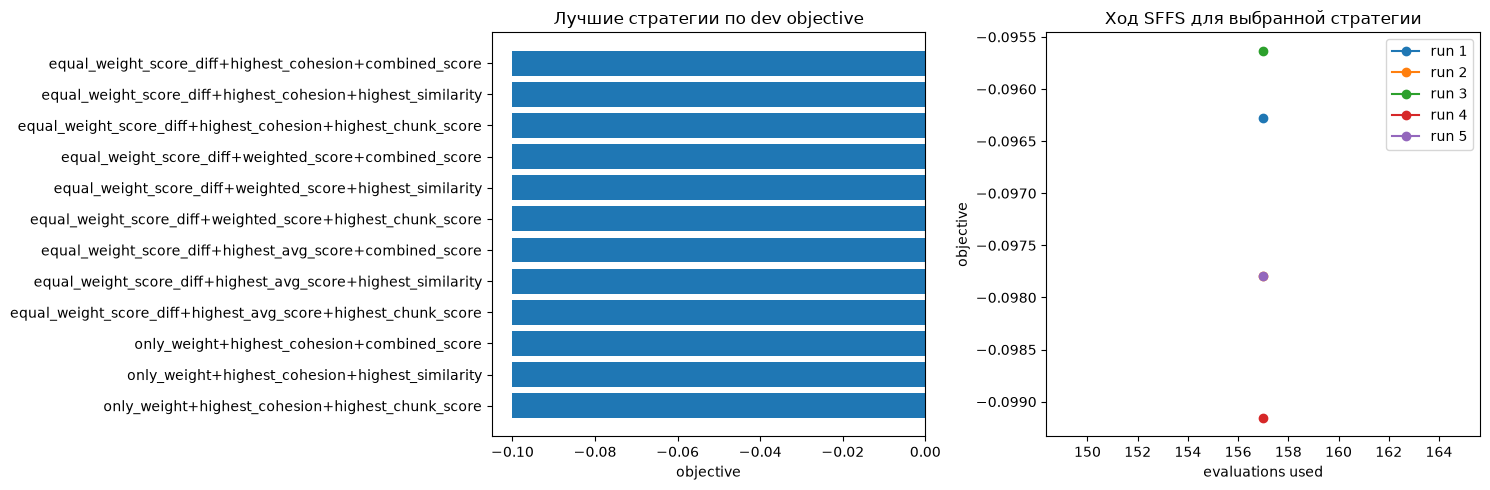

In [6]:
strategy_df = pd.DataFrame(
    [
        {
            "strategy": item.strategy.name,
            "objective": item.objective,
            "mean_gain": item.mean_gain,
            "mean_gain_active": item.mean_gain_active,
            "activation_rate": item.activation_rate,
            "win_rate": item.win_rate,
            "loss_rate": item.loss_rate,
            "harm_rate": item.harm_rate,
            "fallback_rate": item.fallback_rate,
            "stability": item.stability,
            "keyword_count": len(item.keywords),
            "evaluations_used": item.evaluations_used,
            "stop_reasons": " | ".join(item.stop_reasons),
        }
        for item in outcome.strategy_outcomes
    ]
)
display(strategy_df.head(27))
display(pd.DataFrame([asdict(item) for item in outcome.ablations]))

best_strategy = next(item for item in outcome.strategy_outcomes if item.strategy == outcome.strategy)
trace_rows = []
for run_index, trace in enumerate(best_strategy.traces, start=1):
    for step in trace:
        trace_rows.append({"run": run_index, **asdict(step)})
trace_df = pd.DataFrame(trace_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ranked = strategy_df.sort_values("objective").tail(12)
axes[0].barh(ranked["strategy"], ranked["objective"])
axes[0].set_title("Лучшие стратегии по dev objective")
axes[0].set_xlabel("objective")
if not trace_df.empty:
    for run_index, group in trace_df.groupby("run"):
        axes[1].plot(group["evaluations_used"], group["objective"], marker="o", label=f"run {run_index}")
    axes[1].legend()
axes[1].set_title("Ход SFFS для выбранной стратегии")
axes[1].set_xlabel("evaluations used")
axes[1].set_ylabel("objective")
plt.tight_layout()
plt.show()

## Baseline против настроенной модели на held-out test

Сравнение использует сохранённые QA-ответы test-документов из evidence-кэша. `baseline_answer` получен без фильтрации и ключевых слов. `rerank_cached_document` применяет тот же `score_chunks` и кластерный выбор, что `StaticKeywordRerankingPipeline`; их эквивалентность закреплена тестом `test_cached_reranking_matches_live_static_pipeline`. Это исключает повторный дорогой QA и не меняет ответы эксперимента.

In [7]:
weighted_keywords, selected_strategy = load_static_keywords(TUNED_MODEL_PATH, field_id=1)
weight_ratio = {
    "only_score_diff": 0.0,
    "only_weight": 1.0,
    "equal_weight_score_diff": 0.5,
}.get(str(selected_strategy.get("score_chunk_strategy", "")), 0.5)
cluster_strategy = str(selected_strategy.get("choose_cluster_strategy", "weighted_score"))
answer_strategy = str(selected_strategy.get("choose_answer_strategy", "combined_score"))

comparison_rows = []
for doc_id in tqdm(outcome.test_doc_ids, desc="Baseline vs tuned", unit="doc"):
    document = evidence_by_id[doc_id]
    tuned_answer, diagnostics = rerank_cached_document(
        document,
        weighted_keywords,
        weight_ratio=weight_ratio,
        cluster_strategy=cluster_strategy,
        answer_strategy=answer_strategy,
    )
    common = {"doc_id": doc_id, "tasks_cleaned": list(document.references)}
    comparison_rows.append(
        {**common, "mode": "baseline", "prediction": document.baseline_answer, "fallback": False}
    )
    comparison_rows.append(
        {
            **common,
            "mode": "static-keywords",
            "prediction": tuned_answer,
            "fallback": bool(diagnostics.get("fallback", False)),
        }
    )

comparison = pd.DataFrame(comparison_rows)
display(comparison.head(8))
print(f"Test documents: {len(outcome.test_doc_ids)}")
tuned_fallback_rate = comparison.loc[
    comparison["mode"] == "static-keywords", "fallback"
].mean()
print(f"Keyword fallback rate: {tuned_fallback_rate:.3f}")

Baseline vs tuned: 100%|██████████| 62/62 [00:00<00:00, 4757.01doc/s]


,doc_id,tasks_cleaned,mode,prediction,fallback
0,45b559e6271570598602fcf9777ed6f2f2d133e6,[Speech Recognition],baseline,cross - entropy training,False
1,45b559e6271570598602fcf9777ed6f2f2d133e6,[Speech Recognition],static-keywords,cross - entropy training,True
2,0012de6bec1f25599e4f02517637e531a71909b9,[Volumetric Medical Image Segmentation],baseline,classification task,False
3,0012de6bec1f25599e4f02517637e531a71909b9,[Volumetric Medical Image Segmentation],static-keywords,classification task,True
4,13b58f3108709dbbed5588759bc0496f82a261c4,[Atari Games],baseline,Partitioning the Text,False
5,13b58f3108709dbbed5588759bc0496f82a261c4,[Atari Games],static-keywords,Partitioning the Text,True
6,0891ed6ed64fb461bc03557b28c686f87d880c9a,[Named Entity Recognition NER],baseline,Named entity recognition,False
7,0891ed6ed64fb461bc03557b28c686f87d880c9a,[Named Entity Recognition NER],static-keywords,Named entity recognition,True


Test documents: 62
Keyword fallback rate: 1.000


In [8]:
scored = compute_metrics_rowwise(
    comparison,
    pred_col="prediction",
    gold_col="tasks_cleaned",
    lang=LANGUAGE,
    include_bertscore=EVAL_BERTSCORE,
    show_progress=True,
)
metric_columns = [column for column in METRIC_COLUMNS if column in scored.columns]
quality_parts = [scored["char_f1"], scored["token_f1"] / 100.0, scored["rouge_l_f1"]]
if EVAL_BERTSCORE:
    quality_parts.append(scored["bertscore_f1"])
scored["composite_quality"] = sum(quality_parts) / len(quality_parts)

aggregate = scored.groupby("mode")[metric_columns + ["composite_quality"]].mean()
display(aggregate)

wide_quality = scored.pivot(index="doc_id", columns="mode", values="composite_quality")
wide_quality["delta"] = wide_quality["static-keywords"] - wide_quality["baseline"]
epsilon = 1e-9
win_tie_loss = pd.Series(
    {
        "win": int((wide_quality["delta"] > epsilon).sum()),
        "tie": int((wide_quality["delta"].abs() <= epsilon).sum()),
        "loss": int((wide_quality["delta"] < -epsilon).sum()),
        "harm_rate": float((wide_quality["delta"] < -0.01).mean()),
        "mean_delta": float(wide_quality["delta"].mean()),
    },
    name="value",
)
display(win_tie_loss.to_frame())

scored.to_csv(OUTPUT_DIR / "baseline_vs_static_keywords_per_document.csv", index=False)
aggregate.to_csv(OUTPUT_DIR / "baseline_vs_static_keywords_summary.csv")
wide_quality.to_csv(OUTPUT_DIR / "composite_quality_deltas.csv")
print(f"Результаты сохранены в {OUTPUT_DIR}")

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 11005.55it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 12038.72it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UN

,char_f1,token_f1,rouge_l_f1,bertscore_p,bertscore_r,bertscore_f1,composite_quality
mode,,,,,,,
baseline,0.648932,25.604198,0.300866,0.877826,0.875056,0.87629,0.520533
static-keywords,0.648932,25.604198,0.300866,0.877826,0.875056,0.87629,0.520533


,value
win,0.0
tie,62.0
loss,0.0
harm_rate,0.0
mean_delta,0.0


Результаты сохранены в /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/keyword_tuning_task/en/full


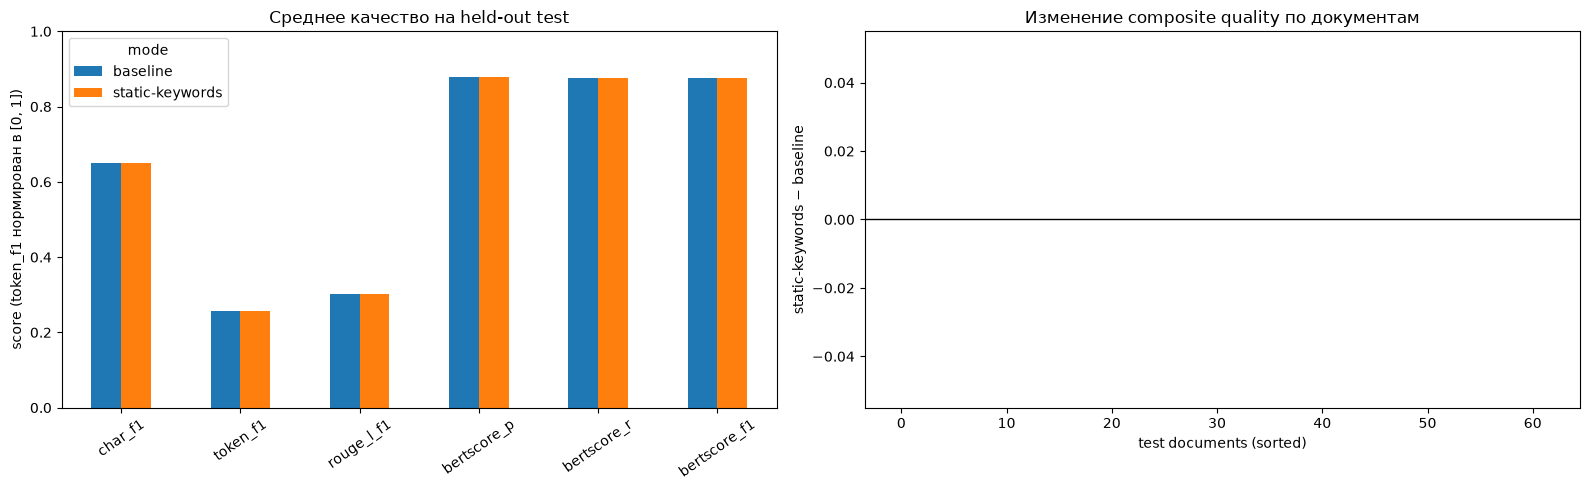

Наибольшие улучшения:


mode,baseline,static-keywords,delta
doc_id,,,
0012de6bec1f25599e4f02517637e531a71909b9,classification task,classification task,0.0
007ab5528b3bd310a80d553cccad4b78dc496b02,answering the query,answering the query,0.0
00b1cdc5bd77bf27f9b1ca630365eeeb456913b4,AlphaZero algorithm,AlphaZero algorithm,0.0
01c824989d24a8cae214c3156edd9d4492faa579,invert a bottom - up mapping,invert a bottom - up mapping,0.0
052443e1709c0f7d3432cca7c451534eea76b7ca,superresolution method,superresolution method,0.0


Наибольшие ухудшения:


mode,baseline,static-keywords,delta
doc_id,,,
3f45d73a7b8d10a59a68688c11950e003f4852fc,person re - identification,person re - identification,0.0
424561d8585ff8ebce7d5d07de8dbf7aae5e7270,region proposal,region proposal,0.0
432d8cba544bf7b09b0455561fea098177a85db1,sample dropout,sample dropout,0.0
44c5dec4d1295d34f052d3243d8e08f14a3c0990,context fragmentation problem,context fragmentation problem,0.0
45b559e6271570598602fcf9777ed6f2f2d133e6,cross - entropy training,cross - entropy training,0.0


In [9]:
plot_data = aggregate[metric_columns].copy()
if "token_f1" in plot_data.columns:
    plot_data["token_f1"] = plot_data["token_f1"] / 100.0

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_data.T.plot(kind="bar", ax=axes[0])
axes[0].set_title("Среднее качество на held-out test")
axes[0].set_ylabel("score (token_f1 нормирован в [0, 1])")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="mode")

axes[1].axhline(0, color="black", linewidth=1)
axes[1].bar(np.arange(len(wide_quality)), wide_quality["delta"].sort_values().values)
axes[1].set_title("Изменение composite quality по документам")
axes[1].set_xlabel("test documents (sorted)")
axes[1].set_ylabel("static-keywords − baseline")
plt.tight_layout()
plt.show()

prediction_wide = scored.pivot(index="doc_id", columns="mode", values="prediction")
examples = prediction_wide.join(wide_quality[["delta"]]).sort_values("delta", ascending=False)
print("Наибольшие улучшения:")
display(examples.head(5))
print("Наибольшие ухудшения:")
display(examples.tail(5).sort_values("delta"))

## Интерпретация

При принятии tuned-модели следует одновременно проверять:

1. положительные `test_mean_gain` и среднюю delta всех метрик;
2. нижнюю bootstrap-границу не ниже нуля;
3. harm rate и примеры наибольших ухудшений;
4. fallback rate — высокий fallback означает, что словарь редко влияет на извлечение;
5. stability и selection frequency ключевых слов;
6. `release_recommended` как автоматический gate, а не как замену ручному анализу.

Для production-вывода повторите ноутбук с `RUN_MODE = "full"`. Начальная модель не перезаписывается: tuned JSON, trace и таблицы сохраняются отдельно.